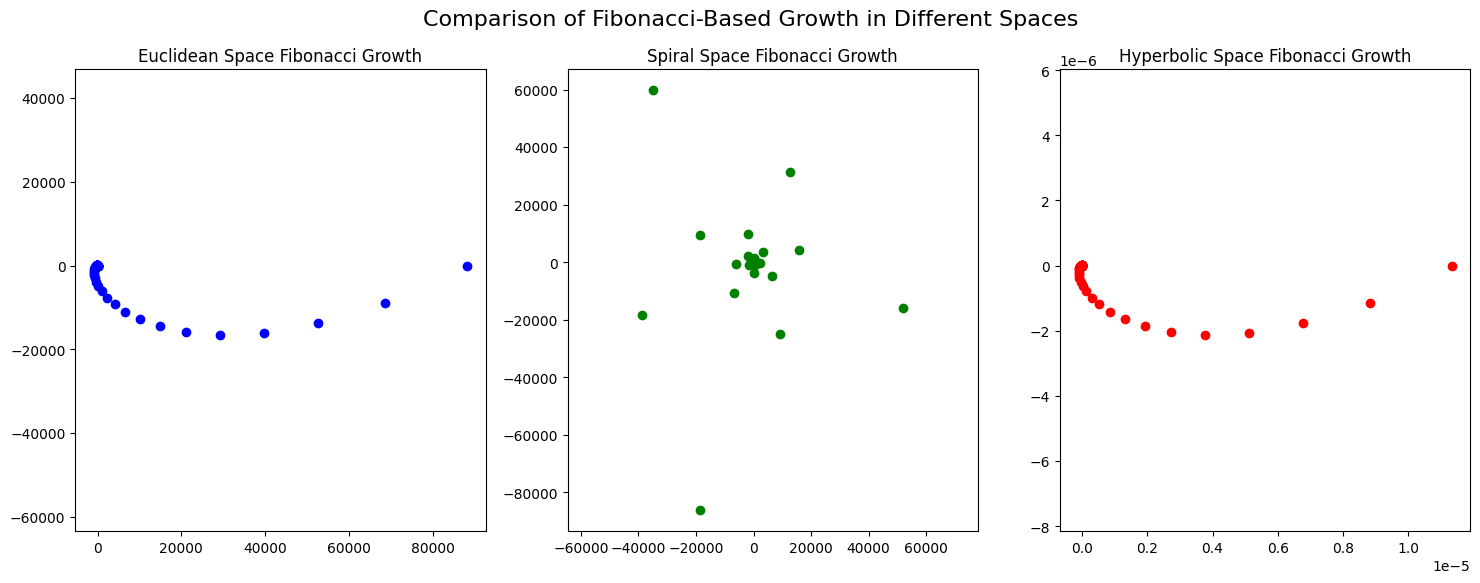

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fibonacci sequence generator
def fibonacci_sequence(n):
    seq = [0, 1]
    for _ in range(2, n):
        seq.append(seq[-1] + seq[-2])
    return seq

# Euclidean Space Growth (Fibonacci Spiral)
def euclidean_fibonacci_spiral(n_points):
    seq = fibonacci_sequence(n_points)
    angles = np.linspace(0, 2 * np.pi, n_points)
    x = [np.sqrt(val) * np.cos(angle) for val, angle in zip(seq, angles)]
    y = [np.sqrt(val) * np.sin(angle) for val, angle in zip(seq, angles)]
    return x, y

# Spiral Space Growth (tight spiral)
def spiral_space_growth(n_points):
    seq = fibonacci_sequence(n_points)
    angles = [i * np.pi * (3 - np.sqrt(5)) for i in range(n_points)]  # Golden angle in radians
    radii = [np.sqrt(val) for val in seq]
    x = [r * np.cos(a) for r, a in zip(radii, angles)]
    y = [r * np.sin(a) for r, a in zip(radii, angles)]
    return x, y

# Hyperbolic Space Growth (Poincaré disk model approximation)
def hyperbolic_space_growth(n_points):
    seq = fibonacci_sequence(n_points)
    angles = np.linspace(0, 2 * np.pi, n_points)
    r = [np.tanh(np.sqrt(val) / max(seq)) for val in seq]  # Hyperbolic scaling
    x = [radius * np.cos(angle) for radius, angle in zip(r, angles)]
    y = [radius * np.sin(angle) for radius, angle in zip(r, angles)]
    return x, y

# Plotting the three growth patterns
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Euclidean Plot
x_euclid, y_euclid = euclidean_fibonacci_spiral(50)
axs[0].scatter(x_euclid, y_euclid, color='blue')
axs[0].set_title('Euclidean Space Fibonacci Growth')
axs[0].axis('equal')

# Spiral Space Plot
x_spiral, y_spiral = spiral_space_growth(50)
axs[1].scatter(x_spiral, y_spiral, color='green')
axs[1].set_title('Spiral Space Fibonacci Growth')
axs[1].axis('equal')

# Hyperbolic Space Plot
x_hyperbolic, y_hyperbolic = hyperbolic_space_growth(50)
axs[2].scatter(x_hyperbolic, y_hyperbolic, color='red')
axs[2].set_title('Hyperbolic Space Fibonacci Growth')
axs[2].axis('equal')

plt.suptitle('Comparison of Fibonacci-Based Growth in Different Spaces', fontsize=16)
plt.show()

<ipython-input-2-5d326616ffe5>:44: RuntimeWarning: invalid value encountered in divide
  positions = np.where(norms[:, None] > max_radius, positions / norms[:, None] * max_radius, positions)


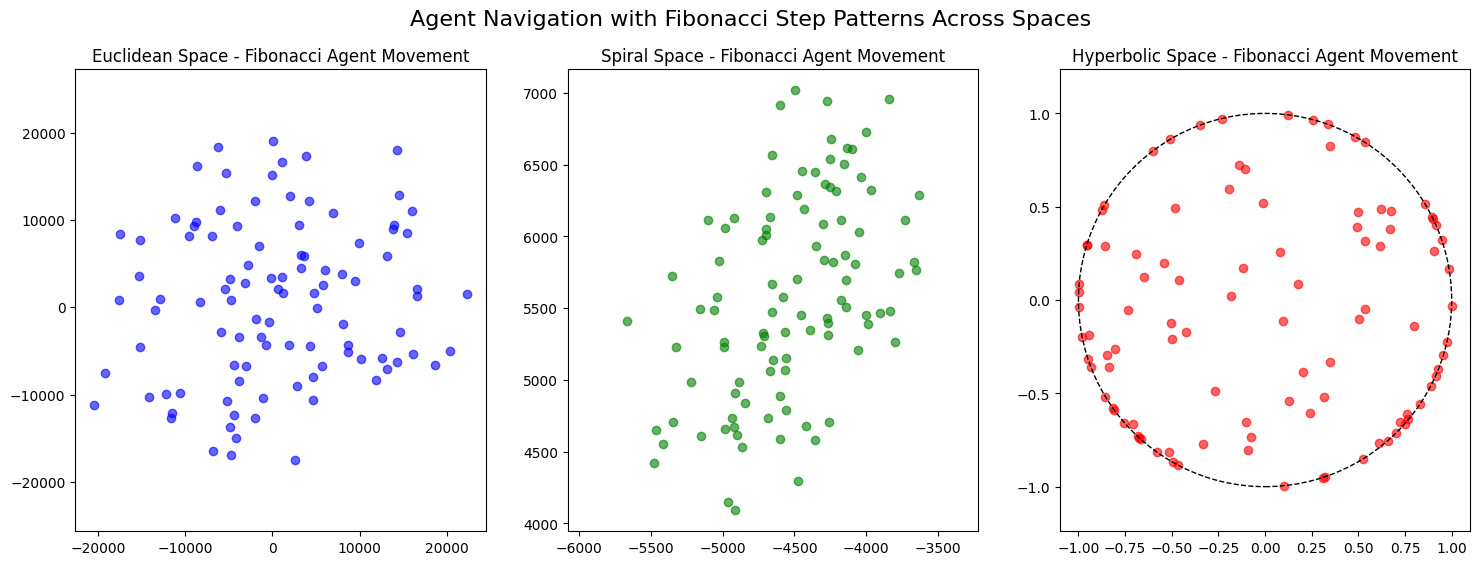

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Number of agents and steps
num_agents = 100
num_steps = 20

# Fibonacci sequence for movement steps
fib_sequence = [0, 1]
for _ in range(num_steps):
    fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])

# Initialize agents at the origin for each environment
def initialize_agents():
    return np.zeros((num_agents, 2))

# Agent movement in Euclidean space
def move_agents_euclidean(positions):
    for step in fib_sequence:
        angles = np.random.uniform(0, 2 * np.pi, num_agents)
        positions[:, 0] += step * np.cos(angles)
        positions[:, 1] += step * np.sin(angles)
    return positions

# Agent movement in Spiral space (modulated by golden angle)
def move_agents_spiral(positions):
    golden_angle = np.pi * (3 - np.sqrt(5))  # ~137.5 degrees
    for i, step in enumerate(fib_sequence):
        angles = golden_angle * (i + 1) + np.random.uniform(-0.1, 0.1, num_agents)
        positions[:, 0] += step * np.cos(angles)
        positions[:, 1] += step * np.sin(angles)
    return positions

# Agent movement in Hyperbolic space (Poincaré disk approximation)
def move_agents_hyperbolic(positions):
    max_radius = 1.0  # Poincaré disk has a boundary at radius 1
    for step in fib_sequence:
        angles = np.random.uniform(0, 2 * np.pi, num_agents)
        r = np.tanh(step / max(fib_sequence))  # Hyperbolic scaling
        positions[:, 0] += r * np.cos(angles)
        positions[:, 1] += r * np.sin(angles)
        # Ensure agents stay within the Poincaré disk boundary
        norms = np.linalg.norm(positions, axis=1)
        positions = np.where(norms[:, None] > max_radius, positions / norms[:, None] * max_radius, positions)
    return positions

# Initialize positions
pos_euclidean = initialize_agents()
pos_spiral = initialize_agents()
pos_hyperbolic = initialize_agents()

# Move agents in each environment
pos_euclidean = move_agents_euclidean(pos_euclidean)
pos_spiral = move_agents_spiral(pos_spiral)
pos_hyperbolic = move_agents_hyperbolic(pos_hyperbolic)

# Plotting the results
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Euclidean Plot
axs[0].scatter(pos_euclidean[:, 0], pos_euclidean[:, 1], color='blue', alpha=0.6)
axs[0].set_title('Euclidean Space - Fibonacci Agent Movement')
axs[0].axis('equal')

# Spiral Plot
axs[1].scatter(pos_spiral[:, 0], pos_spiral[:, 1], color='green', alpha=0.6)
axs[1].set_title('Spiral Space - Fibonacci Agent Movement')
axs[1].axis('equal')

# Hyperbolic Plot
axs[2].scatter(pos_hyperbolic[:, 0], pos_hyperbolic[:, 1], color='red', alpha=0.6)
circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
axs[2].add_artist(circle)
axs[2].set_title('Hyperbolic Space - Fibonacci Agent Movement')
axs[2].axis('equal')

plt.suptitle('Agent Navigation with Fibonacci Step Patterns Across Spaces', fontsize=16)
plt.show()

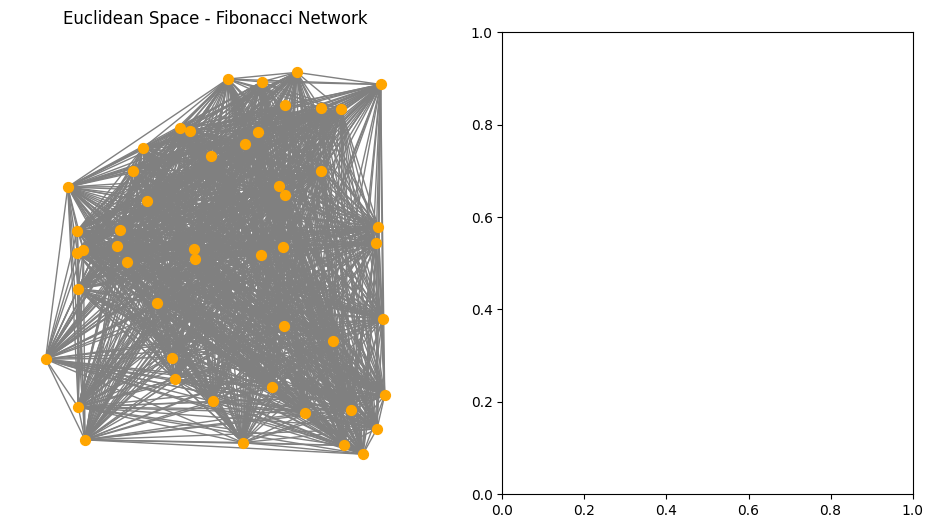

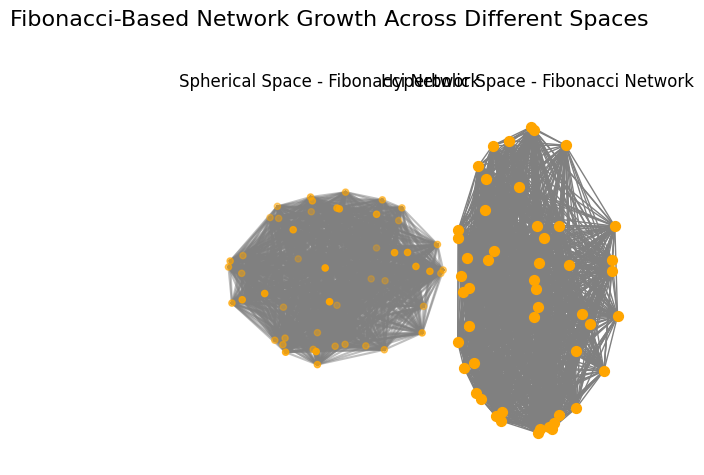

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Number of nodes in each network
num_nodes = 50

# Generate Fibonacci sequence for connection counts
def fibonacci_sequence(n):
    seq = [1, 1]
    for _ in range(2, n):
        seq.append(seq[-1] + seq[-2])
    return seq

fib_seq = fibonacci_sequence(num_nodes)

# Euclidean Network
def build_euclidean_network(n):
    G = nx.Graph()
    positions = np.random.rand(n, 2)  # Random 2D positions for Euclidean space
    for i in range(n):
        G.add_node(i, pos=positions[i])
        num_connections = min(fib_seq[i], i)  # Limit to existing nodes
        targets = np.random.choice(range(i), num_connections, replace=False) if i > 0 else []
        for t in targets:
            G.add_edge(i, t)
    return G

# Spherical Network (nodes on a sphere)
def build_spherical_network(n):
    G = nx.Graph()
    phi = np.random.uniform(0, np.pi, n)  # Latitude
    theta = np.random.uniform(0, 2 * np.pi, n)  # Longitude
    positions = np.array([
        [np.sin(p) * np.cos(t), np.sin(p) * np.sin(t), np.cos(p)] for p, t in zip(phi, theta)
    ])
    for i in range(n):
        G.add_node(i, pos=positions[i])
        num_connections = min(fib_seq[i], i)
        targets = np.random.choice(range(i), num_connections, replace=False) if i > 0 else []
        for t in targets:
            G.add_edge(i, t)
    return G

# Hyperbolic Network (Poincaré disk approximation)
def build_hyperbolic_network(n):
    G = nx.Graph()
    angles = np.random.uniform(0, 2 * np.pi, n)
    radii = np.tanh(np.linspace(0, 3, n))  # Hyperbolic scaling
    positions = np.array([[r * np.cos(a), r * np.sin(a)] for r, a in zip(radii, angles)])
    for i in range(n):
        G.add_node(i, pos=positions[i])
        num_connections = min(fib_seq[i], i)
        targets = np.random.choice(range(i), num_connections, replace=False) if i > 0 else []
        for t in targets:
            G.add_edge(i, t)
    return G

# Updated plotting function to handle 3D visualization for spherical space
def plot_network_updated(G, title, dim=2):
    pos = nx.get_node_attributes(G, 'pos')

    if dim == 3:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        for (u, v) in G.edges():
            x = [pos[u][0], pos[v][0]]
            y = [pos[u][1], pos[v][1]]
            z = [pos[u][2], pos[v][2]]
            ax.plot(x, y, z, color='gray', alpha=0.5)
        ax.scatter(*zip(*pos.values()), color='orange', s=20)
        ax.set_title(title)
        ax.set_axis_off()
    else:
        nx.draw(G, pos, with_labels=False, node_size=50, node_color='orange', edge_color='gray')
        plt.title(title)

# Building the networks
G_euclidean = build_euclidean_network(num_nodes)
G_spherical = build_spherical_network(num_nodes)
G_hyperbolic = build_hyperbolic_network(num_nodes)

# Plotting the networks
fig = plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_network_updated(G_euclidean, 'Euclidean Space - Fibonacci Network')

plt.subplot(1, 3, 2)
plot_network_updated(G_spherical, 'Spherical Space - Fibonacci Network', dim=3)

plt.subplot(1, 3, 3)
plot_network_updated(G_hyperbolic, 'Hyperbolic Space - Fibonacci Network')

plt.suptitle('Fibonacci-Based Network Growth Across Different Spaces', fontsize=16)
plt.tight_layout()
plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
750/750 - 27s - 36ms/step - accuracy: 0.8145 - loss: 0.5154 - val_accuracy: 0.8429 - val_loss: 0.4424
Epoch 2/10
750/750 - 39s - 52ms/step - accuracy: 0.8596 - loss: 0.3834 - val_accuracy: 0.8628 - val_loss: 0.3786
Epoch 3/10
750/750 - 41s - 55ms/step - accuracy: 0.8727 - loss: 0.3463 - val_accuracy: 0.8434 - val_loss: 0.4235
Epoch 4/10
750/750 - 41s - 55ms/step - accuracy: 0.8812 - loss: 0.3247 - val_accuracy: 0.8737 - val_loss: 0.3626
Epoch 5/10
750/750 - 40s - 53ms/step - accuracy: 0.8867 - loss: 0.3087 - val_accuracy: 0.8772 - val_loss: 0.3498
Epoch 6/10
750/750 - 40s - 54ms/step - accuracy: 0.8943 - loss: 0.2872 - val_accuracy: 0.8787 - val_loss: 0.3285
Epoch 7/10
750/750 - 43s - 57ms/step - accuracy: 0.8976 - loss: 0.2766 - val_accuracy: 0.8771 - val_loss: 0.3380
Epoch 8/10
750/750 - 

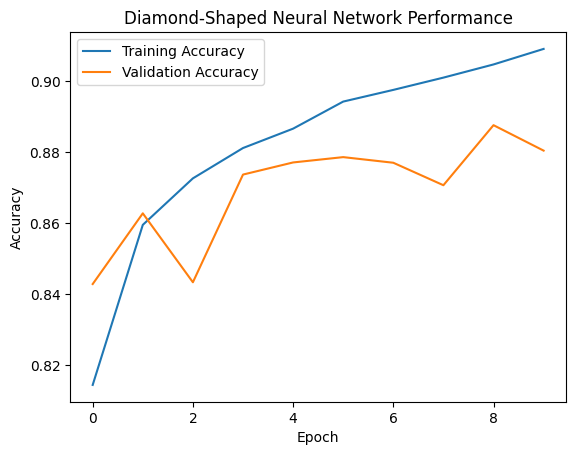

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize the data
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten images for input
train_images = train_images.reshape((-1, 28 * 28))
test_images = test_images.reshape((-1, 28 * 28))

# Define Diamond-shaped Neural Network in Hyperbolic Space
model = models.Sequential()

# Input Layer
model.add(layers.Input(shape=(28*28,)))

# Expanding Layers (Diamond structure begins expanding)
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1024, activation='relu'))  # Peak of the diamond

# Contracting Layers (Diamond structure begins compressing)
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(256, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, epochs=10, batch_size=64,
                    validation_split=0.2, verbose=2)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Diamond-Shaped Neural Network Performance')
plt.show()

Epoch 1/10
750/750 - 21s - 28ms/step - accuracy: 0.8062 - loss: 0.5262 - val_accuracy: 0.8420 - val_loss: 0.4196
Epoch 2/10
750/750 - 19s - 25ms/step - accuracy: 0.8601 - loss: 0.3872 - val_accuracy: 0.8641 - val_loss: 0.3783
Epoch 3/10
750/750 - 20s - 26ms/step - accuracy: 0.8717 - loss: 0.3511 - val_accuracy: 0.8746 - val_loss: 0.3602
Epoch 4/10
750/750 - 19s - 26ms/step - accuracy: 0.8814 - loss: 0.3240 - val_accuracy: 0.8730 - val_loss: 0.3578
Epoch 5/10
750/750 - 19s - 26ms/step - accuracy: 0.8892 - loss: 0.3033 - val_accuracy: 0.8785 - val_loss: 0.3597
Epoch 6/10
750/750 - 22s - 29ms/step - accuracy: 0.8929 - loss: 0.2908 - val_accuracy: 0.8852 - val_loss: 0.3303
Epoch 7/10
750/750 - 18s - 24ms/step - accuracy: 0.8970 - loss: 0.2780 - val_accuracy: 0.8758 - val_loss: 0.3384
Epoch 8/10
750/750 - 22s - 29ms/step - accuracy: 0.9022 - loss: 0.2672 - val_accuracy: 0.8817 - val_loss: 0.3341
Epoch 9/10
750/750 - 18s - 24ms/step - accuracy: 0.9070 - loss: 0.2547 - val_accuracy: 0.8781 - 

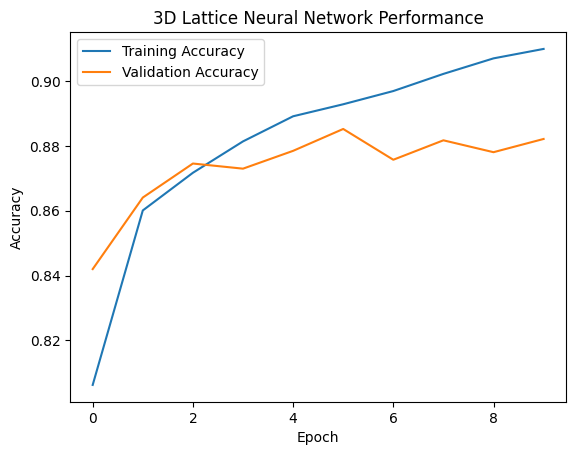

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize the data
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten images for input
train_images = train_images.reshape((-1, 28 * 28))
test_images = test_images.reshape((-1, 28 * 28))

# Define 3D Lattice Neural Network
model = models.Sequential()

# Input Layer
model.add(layers.Input(shape=(28*28,)))

# 3D Lattice Layers (uniform expansion and contraction)
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(512, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, epochs=10, batch_size=64,
                    validation_split=0.2, verbose=2)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('3D Lattice Neural Network Performance')
plt.show()